In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/clean-data/Clean_Data.csv


In [2]:
df = pd.read_csv('/kaggle/input/clean-data/Clean_Data.csv')

In [70]:
df.shape

(2312944, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Unnamed: 0        int64  
 1   Category          object 
 2   Rating            float64
 3   Rating Count      float64
 4   Installs          object 
 5   Minimum Installs  float64
 6   Maximum Installs  int64  
 7   Price             float64
 8   Size              float64
 9   Minimum Android   float64
 10  Released          object 
 11  Last Updated      object 
 12  Content Rating    object 
 13  Ad Supported      bool   
 14  In App Purchases  bool   
 15  Editors Choice    bool   
dtypes: bool(3), float64(6), int64(2), object(5)
memory usage: 236.0+ MB


In [5]:
df.head()

,Unnamed: 0,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Price,Size,Minimum Android,Released,Last Updated,Content Rating,Ad Supported,In App Purchases,Editors Choice
0,0,Adventure,0.0,0.0,10+,10.0,15,0.0,10.0,7.1,2020-02-26,2020-02-26,Everyone,False,False,False
1,1,Tools,4.4,64.0,"5,000+",5000.0,7662,0.0,2.9,5.0,2020-05-21,2021-05-06,Everyone,True,False,False
2,2,Productivity,0.0,0.0,50+,50.0,58,0.0,3.7,4.0,2019-08-09,2019-08-19,Everyone,False,False,False
3,3,Communication,5.0,5.0,10+,10.0,19,0.0,1.8,4.0,2018-09-10,2018-10-13,Everyone,True,False,False
4,4,Tools,0.0,0.0,100+,100.0,478,0.0,6.2,4.1,2020-02-21,2020-02-21,Everyone,False,False,False


In [3]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [5]:
df.head()

,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Price,Size,Minimum Android,Released,Last Updated,Content Rating,Ad Supported,In App Purchases,Editors Choice
0,Adventure,0.0,0.0,10+,10.0,15,0.0,10.0,7.1,2020-02-26,2020-02-26,Everyone,False,False,False
1,Tools,4.4,64.0,"5,000+",5000.0,7662,0.0,2.9,5.0,2020-05-21,2021-05-06,Everyone,True,False,False
2,Productivity,0.0,0.0,50+,50.0,58,0.0,3.7,4.0,2019-08-09,2019-08-19,Everyone,False,False,False
3,Communication,5.0,5.0,10+,10.0,19,0.0,1.8,4.0,2018-09-10,2018-10-13,Everyone,True,False,False
4,Tools,0.0,0.0,100+,100.0,478,0.0,6.2,4.1,2020-02-21,2020-02-21,Everyone,False,False,False


In [4]:
df1 = df.drop(columns=['Released','Last Updated'])

In [5]:
df1 = pd.get_dummies(df1,drop_first=True,dtype=int)

In [8]:
df1.head()

,Rating,Rating Count,Minimum Installs,Maximum Installs,Price,Size,Minimum Android,Ad Supported,In App Purchases,Editors Choice,...,"Installs_5,000,000,000+",Installs_50+,"Installs_50,000+","Installs_50,000,000+",Installs_500+,"Installs_500,000+","Installs_500,000,000+",Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated
0,0.0,0.0,10.0,15,0.0,10.0,7.1,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,4.4,64.0,5000.0,7662,0.0,2.9,5.0,True,False,False,...,0,0,0,0,0,0,0,0,0,0
2,0.0,0.0,50.0,58,0.0,3.7,4.0,False,False,False,...,0,1,0,0,0,0,0,0,0,0
3,5.0,5.0,10.0,19,0.0,1.8,4.0,True,False,False,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0.0,100.0,478,0.0,6.2,4.1,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
import time

# Linear Regression

In [10]:
X = df1.drop(columns=['Maximum Installs'])
y = df1['Maximum Installs']

In [49]:
X_train,X_test,y_train,y_test = train_test_split(x,y,train_size=.70,random_state=42)

In [12]:
print(f'Shape of Xtrain: {X_train.shape}')
print(f'Shape of Xtest: {X_test.shape}')
print(f'Shape of Ytrain: {y_train.shape}')
print(f'Shape of Ytest: {y_test.shape}')

Shape of Xtrain: (1619060, 80)
Shape of Xtest: (693884, 80)
Shape of Ytrain: (1619060,)
Shape of Ytest: (693884,)


In [16]:
lr = LinearRegression()

In [17]:
%%time
lr.fit(X_train,y_train)

CPU times: user 27.9 s, sys: 5.28 s, total: 33.2 s
Wall time: 15 s


LinearRegression()

User Time: This is the amount of time the CPU spent executing user-level code (your Python code).

Interpretation: 23.3 s means that the CPU spent 23.3 seconds running your code

System Time: This is the amount of time the CPU spent executing system-level operations on behalf of your process (e.g., handling I/O operations, memory management).

Interpretation: 4.87 s means that the CPU spent 4.87 seconds on system-level tasks needed for your code to run.

Total Time: This is the sum of user time and system time.

Interpretation: 28.2 s means that in total, 28.2 seconds of CPU time was used to execute your code.

In [18]:
lr_pred = lr.predict(X_test)

In [19]:
print('R2_Score for Linear Regression',r2_score(y_test,lr_pred))
print('RMSE for Linear Regression',np.sqrt(mean_squared_error(y_test,lr_pred)))

R2_Score for Linear Regression 0.9027912047979509
RMSE for Linear Regression 9318985.72203009


## lets apply XGBOOST

In [12]:
from xgboost import XGBRegressor

In [21]:
xgb = XGBRegressor()

In [22]:
%%time
xgb.fit(X_train,y_train)

CPU times: user 1min 40s, sys: 1.96 s, total: 1min 42s
Wall time: 40 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [23]:
xgb_pred = xgb.predict(X_test)

In [24]:
print('R2_Score for Xgboost',r2_score(y_test,xgb_pred))
print('RMSE for Xgboost',np.sqrt(mean_squared_error(y_test,xgb_pred)))

R2_Score for Xgboost 0.8976482063382514
RMSE for Xgboost 9562327.086589608


# Gradient Boosting

In [25]:
gb = GradientBoostingRegressor()

In [26]:
%%time
gb.fit(X_train,y_train)

CPU times: user 9min 47s, sys: 239 ms, total: 9min 47s
Wall time: 9min 49s


GradientBoostingRegressor()

In [27]:
gb_pred = gb.predict(X_test)

In [29]:
print('R2_Score for Gradient Boosting',r2_score(y_test,gb_pred))
print('RMSE for Gradient Boosting',np.sqrt(mean_squared_error(y_test,gb_pred)))

R2_Score for Gradient Boosting 0.8263250091880698
RMSE for Gradient Boosting 12456169.47098057


## lets make a new column called average installs because the column maximum installs contains very extreme positive values

In [14]:
df1['Average Installs']=(df1['Maximum Installs'] + df1['Minimum Installs']) / 2

In [14]:
df1[['Maximum Installs','Average Installs']].corr()

,Maximum Installs,Average Installs
Maximum Installs,1.000000,0.992952
Average Installs,0.992952,1.000000


In [15]:
df1[['Minimum Installs','Average Installs']].corr()

,Minimum Installs,Average Installs
Minimum Installs,1.000000,0.982832
Average Installs,0.982832,1.000000


In [15]:
xx = df1.drop(columns=['Maximum Installs','Average Installs'])
yy = df1['Average Installs']

##### If we drop both the columns then the r2 is coming out to be only 67% but when we drop only 
##### one of the columns then the r2 we observe is very good and rmse is also very low if we compare 
##### it to the previous one where we had maximum installs as the target column and there the column
##### had very extreme outliers

In [16]:
xx_train,xx_test,yy_train,yy_test = train_test_split(xx,yy,train_size=.70,random_state=42)

In [17]:
print(f'Shape of Xtrain: {xx_train.shape}')
print(f'Shape of Xtest: {xx_test.shape}')
print(f'Shape of Ytrain: {yy_train.shape}')
print(f'Shape of Ytest: {yy_test.shape}')

Shape of Xtrain: (1619060, 80)
Shape of Xtest: (693884, 80)
Shape of Ytrain: (1619060,)
Shape of Ytest: (693884,)


In [19]:
lr1 = LinearRegression()

In [46]:
%%time
lr1.fit(xx_train,yy_train)

CPU times: user 28.5 s, sys: 4.83 s, total: 33.3 s
Wall time: 15.4 s


LinearRegression()

In [47]:
lr1_pred = lr1.predict(xx_test)

In [48]:
print('R2_Score for Average Installs columns',r2_score(yy_test,lr1_pred))
print('RMSE for Average Installs columns',np.sqrt(mean_squared_error(yy_test,lr1_pred)))

R2_Score for Average Installs columns 0.9638989754859637
RMSE for Average Installs columns 4659492.861014823


When I dropped the column Minimum Installs it gave me an rscore of 94% and rmse 
of 60 lakhs even though the correlation between the minimum installs and average installs is lesser 

## Let's use ADABoost wit GridSearchCV

In [13]:
from sklearn.ensemble import AdaBoostRegressor

In [35]:
params = {'n_estimators':[50,75,100,125,150,200],
             'learning_rate':[.01,.10,.05,.075,.001]}

In [36]:
gscv = GridSearchCV(estimator=AdaBoostRegressor(),param_grid=params,cv=5,scoring='neg_mean_squared_error')

In [37]:
%%time
gscv.fit(xx_train,yy_train)

KeyboardInterrupt: 

In [18]:
from xgboost import XGBRegressor

### Lets apply XGBOOST

In [49]:
xgb1 = XGBRegressor()

In [50]:
%%time
xgb1.fit(xx_train,yy_train)

CPU times: user 1min 41s, sys: 2.05 s, total: 1min 43s
Wall time: 40.4 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [51]:
xgb1_pred = xgb1.predict(xx_test)

In [52]:
print('R2_Score for Average Installs columns',r2_score(yy_test,xgb1_pred))
print('RMSE for Average Installs columns',np.sqrt(mean_squared_error(yy_test,xgb1_pred)))

R2_Score for Average Installs columns 0.9193406701101083
RMSE for Average Installs columns 6964760.58397429


## Let's use cross val score on Linear Regression

In [19]:
from sklearn.model_selection import cross_val_score

In [34]:
%%time
linear_cross_scores = cross_val_score(estimator=LinearRegression(),X=xx,y=yy,scoring='neg_mean_squared_error',cv=3)

CPU times: user 1min 35s, sys: 19.7 s, total: 1min 55s
Wall time: 47.8 s


In [39]:
np.mean(np.sqrt(-linear_cross_scores))

3370887.5764539004

### As we can see the rmse is very less as compared to the Linear Regression Model without Cross Val so lets do one more thing lets increase the splits to 5 and try

In [42]:
%%time
linear_5_cross_scores = cross_val_score(estimator=LinearRegression(),X=xx,y=yy,scoring='neg_mean_squared_error',cv=5)

CPU times: user 3min 12s, sys: 39.6 s, total: 3min 51s
Wall time: 1min 34s


In [47]:
np.mean(np.sqrt(-linear_5_cross_scores))

3406598.3786759987

### Let's do it again with 10 cross scores

In [18]:
%%time
linear_10_cross_scores = cross_val_score(estimator=LinearRegression(),X=xx,y=yy,scoring='neg_mean_squared_error',cv=10)

CPU times: user 5min 41s, sys: 1min, total: 6min 42s
Wall time: 2min 58s


In [20]:
np.mean(np.sqrt(-linear_10_cross_scores))

3316503.403916586

## Lets use cross val with XGBoost

In [20]:
%%time
linear_10_cross_scores = cross_val_score(estimator=XGBRegressor(),X=xx,y=yy,scoring='neg_mean_squared_error',cv=10)

CPU times: user 19min 45s, sys: 28 s, total: 20min 13s
Wall time: 7min 14s


In [25]:
np.mean(np.sqrt(-linear_10_cross_scores))

4479762.704401052

## Now lets treat outliers and then run the model again

In [26]:
import seaborn as sns

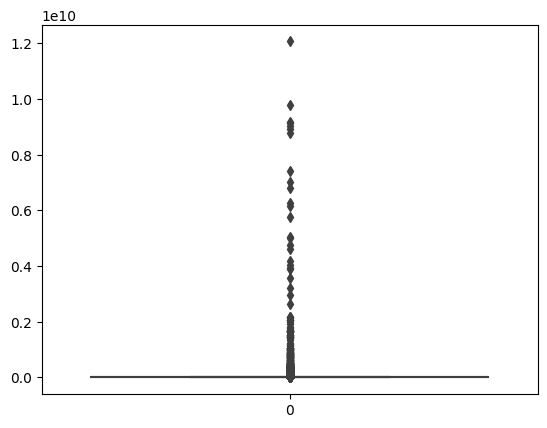

In [27]:
sns.boxplot(df1['Maximum Installs']);

In [41]:
ul = df1['Maximum Installs'].quantile(.999)

In [44]:
df1['Maximum Installs']=np.where(df1['Maximum Installs']>ul,ul,df1['Maximum Installs'])

<Axes: >

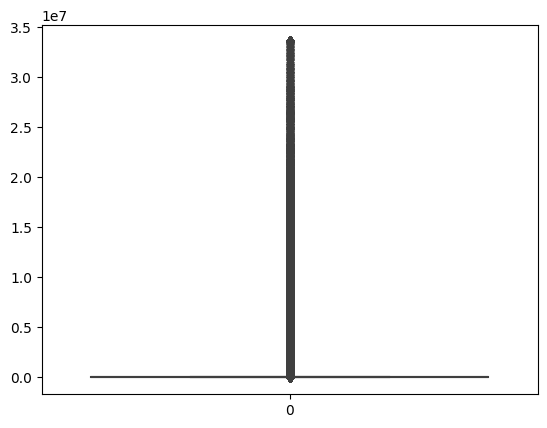

In [45]:
sns.boxplot(df1['Maximum Installs'])

In [47]:
x = df1.drop(columns=['Maximum Installs'])
y = df1['Maximum Installs']

In [51]:
%%time
linear_cross_scores = cross_val_score(estimator=LinearRegression(),X=x,y=y,scoring='neg_mean_squared_error',cv=10)

CPU times: user 5min 50s, sys: 1min, total: 6min 50s
Wall time: 3min 4s


In [54]:
np.mean(np.sqrt(-linear_cross_scores))

436212.6237169377

## Random Forest

In [58]:
from xgboost import XGBRegressor

In [59]:
%%time
xgb_cross_scores = cross_val_score(estimator=XGBRegressor(),X=x,y=y,scoring='neg_mean_squared_error',cv=3)

CPU times: user 4min 53s, sys: 8.32 s, total: 5min 1s
Wall time: 1min 54s


In [60]:
np.mean(np.sqrt(-xgb_cross_scores))

395294.0808305031

## Classification Problem

# lets solve classification with target variable as Editor's Choice

In [21]:
df1.head()

,Rating,Rating Count,Minimum Installs,Maximum Installs,Price,Size,Minimum Android,Ad Supported,In App Purchases,Editors Choice,...,Installs_50+,"Installs_50,000+","Installs_50,000,000+",Installs_500+,"Installs_500,000+","Installs_500,000,000+",Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated,Average Installs
0,0.0,0.0,10.0,15,0.0,10.0,7.1,False,False,False,...,0,0,0,0,0,0,0,0,0,12.5
1,4.4,64.0,5000.0,7662,0.0,2.9,5.0,True,False,False,...,0,0,0,0,0,0,0,0,0,6331.0
2,0.0,0.0,50.0,58,0.0,3.7,4.0,False,False,False,...,1,0,0,0,0,0,0,0,0,54.0
3,5.0,5.0,10.0,19,0.0,1.8,4.0,True,False,False,...,0,0,0,0,0,0,0,0,0,14.5
4,0.0,0.0,100.0,478,0.0,6.2,4.1,False,False,False,...,0,0,0,0,0,0,0,0,0,289.0


In [62]:
x_full = df1.drop(columns=['Editors Choice'])
y_full = df1['Editors Choice']

In [24]:
x,x_unknown,y,y_unknown = train_test_split(x_full,y_full,train_size=.80,random_state=42,stratify=y_full)

In [25]:
print(x.shape),print(y.shape),print(x_unknown.shape),print(y_unknown.shape)

(1850355, 80)
(1850355,)
(462589, 80)
(462589,)


(None, None, None, None)

In [26]:
y.value_counts()

Editors Choice
False    1849673
True         682
Name: count, dtype: int64

In [27]:
y_unknown.value_counts()

Editors Choice
False    462418
True        171
Name: count, dtype: int64

In [37]:
df2 = pd.concat([x,y],axis=1)

In [38]:
df2.head()

,Rating,Rating Count,Minimum Installs,Maximum Installs,Price,Size,Minimum Android,Ad Supported,In App Purchases,Category_Adventure,...,Installs_50+,"Installs_50,000+","Installs_50,000,000+",Installs_500+,"Installs_500,000+","Installs_500,000,000+",Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated,Editors Choice
1550529,0.0,0.0,5.0,8,0.0,5.8,4.4,True,False,0,...,0,0,0,0,0,0,1,0,0,False
1235881,3.2,87.0,5000.0,9885,0.0,67.0,4.1,False,False,0,...,0,0,0,0,0,0,0,0,0,False
1613050,0.0,0.0,1.0,2,0.0,8.4,4.4,False,False,0,...,0,0,0,0,0,0,0,0,0,False
1867762,4.4,927.0,1000000.0,2994287,0.0,4.3,4.2,False,False,0,...,0,0,0,0,0,0,0,0,0,False
1471671,0.0,0.0,5.0,9,0.0,3.8,4.4,True,False,0,...,0,0,0,0,0,0,0,0,0,False


In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=.70,stratify=y)

In [29]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((1295248, 80), (1295248,), (555107, 80), (555107,))

In [30]:
y_train.value_counts()

Editors Choice
False    1294771
True         477
Name: count, dtype: int64

In [31]:
y_test.value_counts()

Editors Choice
False    554902
True        205
Name: count, dtype: int64

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

In [57]:
log = LogisticRegression()

In [58]:
%%time
log.fit(x_train,Y_train)

CPU times: user 2min 11s, sys: 35.4 s, total: 2min 46s
Wall time: 45.3 s


LogisticRegression()

In [59]:
log_pred = log.predict(x_test)

In [60]:
print('Accuracy Score',accuracy_score(Y_test,log_pred))
print('Precision Score',precision_score(Y_test,log_pred))
print('Recall Score',recall_score(Y_test,log_pred))

Accuracy Score 0.9996022389909552
Precision Score 0.2857142857142857
Recall Score 0.014814814814814815


In [ ]:
print('Confusion matrix:\n',confusion_matrix(Y_test,log_pred))

# lets adjust the class weights

In [61]:
log_class = LogisticRegression(class_weight={0:1,1:4})

In [62]:
%%time
log_class.fit(x_train,Y_train)

CPU times: user 39.7 s, sys: 11.6 s, total: 51.2 s
Wall time: 15.6 s


LogisticRegression(class_weight={0: 1, 1: 4})

In [63]:
log_class_pred = log_class.predict(x_test)

In [ ]:
print('Accuracy Score',accuracy_score(Y_test,log_class_pred))
print('Precision Score',precision_score(Y_test,log_class_pred))
print('Recall Score',recall_score(Y_test,log_class_pred))

# Lets apply Grid Search CV to find the best parameters

In [12]:
from sklearn.model_selection import GridSearchCV

In [14]:
params = {'class_weight':[{0:1,1:2},{0:1,1:3},{0:1,1:4},{0:2,1:7}]}

In [15]:
gscv = GridSearchCV(estimator=LogisticRegression(),param_grid=params,cv=3,scoring='f1_macro')

In [16]:
%%time
gscv.fit(x_train,Y_train)

CPU times: user 8min 43s, sys: 2min 24s, total: 11min 8s
Wall time: 3min 18s


GridSearchCV(cv=3, estimator=LogisticRegression(),
             param_grid={'class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3},
                                          {0: 1, 1: 4}, {0: 2, 1: 7}]},
             scoring='f1_macro')

In [17]:
gscv.best_estimator_

LogisticRegression(class_weight={0: 1, 1: 2})

In [18]:
gscv.best_estimator_.get_params()

{'C': 1.0,
 'class_weight': {0: 1, 1: 2},
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [19]:
final_log = LogisticRegression(**gscv.best_estimator_.get_params())

In [20]:
%%time
final_log.fit(x_train,Y_train)

CPU times: user 35.6 s, sys: 9.45 s, total: 45.1 s
Wall time: 13.6 s


LogisticRegression(class_weight={0: 1, 1: 2})

In [21]:
final_pred = final_log.predict(x_test)

In [22]:
print('Accuracy Score',accuracy_score(Y_test,final_pred))
print('Precision Score',precision_score(Y_test,final_pred))
print('Recall Score',recall_score(Y_test,final_pred))

Accuracy Score 0.9253506349764514
Precision Score 0.0012968913321203205
Recall Score 0.24814814814814815


In [ ]:
# lets apply some ensemble technique

In [13]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [15]:
from sklearn.metrics import classification_report

## XGBCLASSIFIER

In [26]:
xgb = XGBClassifier()

In [27]:
%%time
xgb.fit(x_train,Y_train)

CPU times: user 2min 49s, sys: 2.47 s, total: 2min 52s
Wall time: 1min 1s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [28]:
xgb_pred = xgb.predict(x_test)

In [29]:
print('Accuracy Score',accuracy_score(Y_test,xgb_pred))
print('Precision Score',precision_score(Y_test,xgb_pred))
print('Recall Score',recall_score(Y_test,xgb_pred))

Accuracy Score 0.9996108859694127
Precision Score 0.5
Recall Score 0.037037037037037035


### let's deal with these by creating our own model.

In [14]:
df1['Editors Choice'].value_counts()

Editors Choice
False    2312091
True         853
Name: count, dtype: int64

1. To create a a list of all the indexes where it contains only editors choice where it is false 
2. then i have to randomly select around 3600 indexes from that list
3. Then make a dataframe of that with the editors choice with true
4. Train and test split 
5. Store the model in a variable
6. Make the average of that 

In [39]:
indices = df2[df2['Editors Choice']==False].index

In [33]:
df1.shape

(2312944, 81)

In [79]:
li = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]
rand = []
for i in range(0,len(li),4):
    rand.append(li[i:i+3])

In [40]:
df2['Editors Choice'].value_counts()

Editors Choice
False    1849673
True         682
Name: count, dtype: int64

In [41]:
%%time
scores = []
accuracy = []
precision = []
recall = []
f1 = []
log = LogisticRegression(class_weight = {0:1,1:2},max_iter=1000)
for i in range(0,len(indices),2800):
        indice = []
        indice.extend(indices[i:i+2800])
        df = df2[df2.index.isin(indice)]
        df = pd.concat( (df,df2[df2['Editors Choice']==True]),axis=0 )
        x = df.drop(columns='Editors Choice')
        y = df['Editors Choice']
        x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=.70,random_state=42)
        log.fit(x_train,y_train)
        pred = log.predict(x_test)
        accuracy.append(accuracy_score(y_test,pred))
        precision.append(precision_score(y_test,pred))
        
        recall.append(recall_score(y_test,pred))
        f1.append(f1_score(y_test,pred))

CPU times: user 4min 7s, sys: 3min 7s, total: 7min 14s
Wall time: 1min 54s


In [42]:
np.mean(accuracy)

0.43982116637835106

In [43]:
np.mean(precision)

0.3193526489059452

In [44]:
np.mean(recall)

0.9773895574696477

In [45]:
np.mean(f1)

0.4438001212763671

In [67]:
log_pred = log.predict(x_unknown)

In [68]:
print("Accuracy of ADA on unknown dataset",accuracy_score(y_unknown,log_pred))
print("Precision of ADA on unknown dataset",precision_score(y_unknown,log_pred))
print("Recall of ADA on unknown dataset",recall_score(y_unknown,log_pred))
print("F1 of ADA on unknown dataset",f1_score(y_unknown,log_pred))

Accuracy of ADA on unknown dataset 0.9457099066341829
Precision of ADA on unknown dataset 0.006294287637069
Recall of ADA on unknown dataset 0.9298245614035088
F1 of ADA on unknown dataset 0.012503932054105067


### With ensemble techniques

In [47]:
from sklearn.ensemble import AdaBoostClassifier

In [48]:
%%time
scores = []
accuracy = []
precision = []
recall = []
f1 = []
# log = LogisticRegression(class_weight = {0:1,1:2},max_iter=1000)
ada = AdaBoostClassifier(n_estimators=50)
for i in range(0,len(indices),2800):
        indice = []
        indice.extend(indices[i:i+2800])
        df = df2[df2.index.isin(indice)]
        df = pd.concat( (df,df2[df2['Editors Choice']==True]),axis=0 )
        x = df.drop(columns='Editors Choice')
        y = df['Editors Choice']
        x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=.70,random_state=42)
        ada.fit(x_train,y_train)
        pred = ada.predict(x_test)
        accuracy.append(accuracy_score(y_test,pred))
        precision.append(precision_score(y_test,pred))
        
        recall.append(recall_score(y_test,pred))
        f1.append(f1_score(y_test,pred))

CPU times: user 3min 56s, sys: 793 ms, total: 3min 57s
Wall time: 3min 56s


In [49]:
np.mean(accuracy)

0.971524515640171

In [51]:
np.mean(precision)

0.9146403809950916

In [52]:
np.mean(recall)

0.9394474262386059

In [53]:
np.mean(f1)

0.9267348969344907

In [54]:
ada_pred = ada.predict(x_unknown)

In [57]:
print("Accuracy of ADA on unknown dataset",accuracy_score(y_unknown,ada_pred))
print("Precision of ADA on unknown dataset",precision_score(y_unknown,ada_pred))
print("Recall of ADA on unknown dataset",recall_score(y_unknown,ada_pred))
print("F1 of ADA on unknown dataset",f1_score(y_unknown,ada_pred))

Accuracy of ADA on unknown dataset 0.9718108299159729
Precision of ADA on unknown dataset 0.012648640460501402
Recall of ADA on unknown dataset 0.9766081871345029
F1 of ADA on unknown dataset 0.024973829819051892


In [58]:
from sklearn.metrics import confusion_matrix

In [60]:
import seaborn as sns

In [62]:
pd.set_option('display.float_format', '{:,.2f}'.format)

<Axes: >

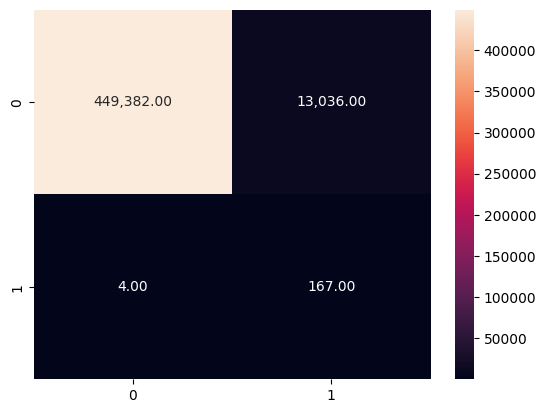

In [66]:
sns.heatmap(confusion_matrix(y_unknown,ada_pred),annot=True,fmt=',.2f')

## Let's improvise this code

In [23]:
from sklearn.model_selection import  StratifiedShuffleSplit,StratifiedKFold

In [65]:
%%time
scores = []
accuracy = []
precision = []
recall = []
f1 = []
# log = LogisticRegression(class_weight = 'balanced',max_iter=1000)
# ada = AdaBoostClassifier(n_estimators=50,learning_rate=.01,random_state=42,)
rf = RandomForestClassifier(n_estimators=50,min_samples_split=5,max_depth=10)
for i in range(0,len(indices),3600):
        indice = []
        indice.extend(indices[i:i+3600])
        df = df1[df1.index.isin(indice)]
        df = pd.concat( (df,df1[df1['Editors Choice']==True]),axis=0 )
        x = df.drop(columns='Editors Choice')
        y = df['Editors Choice']
        x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=.70,random_state=42,stratify=y)
        rf.fit(x_train,y_train)
        y_train_pred = rf.predict(x_test)
        y_test_pred = rf.predict(x_test)
        
        accuracy.append(accuracy_score(y_test,pred))
        precision.append(precision_score(y_test,pred))
        
        recall.append(recall_score(y_test,pred))
        f1.append(f1_score(y_test,pred))

CPU times: user 2min 57s, sys: 771 ms, total: 2min 58s
Wall time: 2min 56s


The Random Forest instance (rf) will have the learning power from all the trained models within the loop. Each iteration of the loop trains the Random Forest model on a different subset of the data, contributing to its overall learning.

In [66]:
len(np.array(accuracy)[np.array(accuracy)>.90])

643

In [86]:
len(accuracy)

643

In [87]:
np.mean(accuracy)

0.9753274013036692

In [92]:
np.mean(precision)

0.919046724511079

In [93]:
np.mean(recall)

0.955858767496112

In [94]:
np.mean(f1)

0.9369924109025393

When I trained ADABoostClassifier,RandomForestClassifier i noticed very amazing thing which is that every model of all the 643 models perfomed so well that they achived accuracy or precision or recall or f1 very close to 90,but with logistic regression only 72 models were giving accuracy of more than 90

## Let's use balancerandom forest regressor

In [61]:
from imblearn.ensemble import BalancedRandomForestClassifier

In [63]:
X = df1.drop(columns=['Editors Choice'])
y = df1['Editors Choice']

In [64]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
# Applying SMOTE
classifier = BalancedRandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)


/opt/conda/lib/python3.10/site-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/opt/conda/lib/python3.10/site-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/opt/conda/lib/python3.10/site-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


BalancedRandomForestClassifier(random_state=42)

In [66]:
# Predict test set
y_pred_brf = classifier.predict(X_test)

In [68]:
from sklearn.metrics import classification_report

In [69]:
# Print classification report for SMOTE data
print("Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_brf))

Classification Report (With SMOTE):
              precision    recall  f1-score   support

       False       1.00      0.96      0.98    462415
        True       0.01      0.99      0.02       174

    accuracy                           0.96    462589
   macro avg       0.50      0.98      0.50    462589
weighted avg       1.00      0.96      0.98    462589



In [120]:
df3 = pd.DataFrame(classifier.feature_importances_,index=X.columns,columns=['Feature Importances'])

In [123]:
df3.sort_values(by='Feature Importances',ascending=False).T

,Rating Count,Average Installs,Minimum Installs,Maximum Installs,Size,Rating,In App Purchases,"Installs_10,000,000+",Installs_100+,Minimum Android,"Installs_1,000,000+","Installs_1,000+","Installs_5,000,000+",Price,Ad Supported,Installs_10+,Content Rating_Teen,Category_Role Playing,Category_Tools,Category_Puzzle,"Installs_100,000+","Installs_10,000+","Installs_500,000+",Category_Personalization,Category_Entertainment,Category_Music & Audio,"Installs_50,000,000+","Installs_100,000,000+",Category_Photography,"Installs_50,000+",Category_Lifestyle,Category_Health & Fitness,Category_Books & Reference,Category_Adventure,Category_Education,"Installs_5,000+",Installs_500+,Installs_50+,Category_Casual,Category_Simulation,Category_Arcade,Content Rating_Mature 17+,Category_Casino,Category_Educational,Category_Shopping,Category_Productivity,Category_Business,Category_Finance,Category_Racing,Category_Video Players & Editors,Category_Weather,Category_Food & Drink,Category_Sports,Category_Card,Category_Word,Category_Maps & Navigation,Category_Trivia,Category_Comics,Category_Communication,Category_News & Magazines,Category_Travel & Local,Category_Medical,Category_Strategy,"Installs_500,000,000+",Category_Social,Category_Art & Design,Category_Board,Category_House & Home,Category_Music,Category_Parenting,Category_Beauty,Category_Auto & Vehicles,Category_Events,"Installs_5,000,000,000+","Installs_1,000,000,000+",Installs_1+,Installs_5+,Category_Dating,Category_Libraries & Demo,Content Rating_Unrated,"Installs_10,000,000,000+"
Feature Importances,0.241267,0.231573,0.137335,0.13463,0.046937,0.046301,0.045082,0.018177,0.011294,0.009961,0.006879,0.005804,0.004803,0.004644,0.004637,0.004053,0.003477,0.003408,0.002937,0.002608,0.002338,0.002053,0.001879,0.00152,0.001458,0.001452,0.001362,0.001358,0.001215,0.001202,0.001143,0.001072,0.001026,0.000975,0.000895,0.000756,0.000732,0.000713,0.000698,0.000676,0.000601,0.000518,0.000485,0.000468,0.000442,0.000432,0.000426,0.000413,0.00041,0.000401,0.000371,0.000349,0.000319,0.000305,0.000302,0.000299,0.000298,0.000266,0.000265,0.000254,0.000234,0.000234,0.000228,0.000219,0.000194,0.000194,0.00019,0.000151,0.000141,0.000083,0.000064,0.000034,0.000029,0.000029,0.00001,0.000007,1.469091e-07,0.0,0.0,0.0,0.0


,0
Rating,0.046301
Rating Count,0.241267
Minimum Installs,0.137335
Maximum Installs,0.134630
Price,0.004644
...,...
"Installs_500,000,000+",0.000219
Content Rating_Mature 17+,0.000518
Content Rating_Teen,0.003477
Content Rating_Unrated,0.000000


## Lets' do a classification problem with target variable as Installs column

In [103]:
df.head()

,Rating,Rating Count,Minimum Installs,Maximum Installs,Price,Size,Minimum Android,Ad Supported,In App Purchases,Editors Choice,...,"Installs_5,000,000,000+",Installs_50+,"Installs_50,000+","Installs_50,000,000+",Installs_500+,"Installs_500,000+","Installs_500,000,000+",Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated
2312053,4.1,99.0,10000.0,11672,0.0,7.600000,4.0,True,False,False,...,0,0,0,0,0,0,0,0,0,0
2312054,0.0,0.0,10.0,28,0.0,130.000000,6.0,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2312055,2.9,114.0,10000.0,38247,0.0,15.000000,4.4,True,False,False,...,0,0,0,0,0,0,0,0,0,0
2312056,0.0,0.0,10.0,21,0.0,9.400000,4.1,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2312057,5.0,7.0,100.0,199,0.0,0.887695,3.0,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [71]:
df2 = df.drop(columns=['Released','Last Updated','Installs'],axis=1)

In [72]:
df2 = pd.get_dummies(df2,drop_first=True,dtype=int)

In [73]:
df2 = pd.concat((df2,df['Installs']),axis=1)

In [74]:
pd.set_option('display.max_columns',None)

In [111]:
df2.head()

,Rating,Rating Count,Minimum Installs,Maximum Installs,Price,Size,Minimum Android,Ad Supported,In App Purchases,Editors Choice,Category_Adventure,Category_Arcade,Category_Art & Design,Category_Auto & Vehicles,Category_Beauty,Category_Board,Category_Books & Reference,Category_Business,Category_Card,Category_Casino,Category_Casual,Category_Comics,Category_Communication,Category_Dating,Category_Education,Category_Educational,Category_Entertainment,Category_Events,Category_Finance,Category_Food & Drink,Category_Health & Fitness,Category_House & Home,Category_Libraries & Demo,Category_Lifestyle,Category_Maps & Navigation,Category_Medical,Category_Music,Category_Music & Audio,Category_News & Magazines,Category_Parenting,Category_Personalization,Category_Photography,Category_Productivity,Category_Puzzle,Category_Racing,Category_Role Playing,Category_Shopping,Category_Simulation,Category_Social,Category_Sports,Category_Strategy,Category_Tools,Category_Travel & Local,Category_Trivia,Category_Video Players & Editors,Category_Weather,Category_Word,Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated,Installs
0,0.0,0.0,10.0,15,0.0,10.0,7.1,False,False,False,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10+
1,4.4,64.0,5000.0,7662,0.0,2.9,5.0,True,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,"5,000+"
2,0.0,0.0,50.0,58,0.0,3.7,4.0,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50+
3,5.0,5.0,10.0,19,0.0,1.8,4.0,True,False,False,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10+
4,0.0,0.0,100.0,478,0.0,6.2,4.1,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,100+


In [76]:
df2.shape

(2312944, 61)

In [85]:
from sklearn.linear_model import LogisticRegression

In [86]:
log_reg = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, n_jobs=-1)

In [87]:
XX = df2.drop(columns=['Installs'])
YY = df2['Installs']

In [88]:
XX_train,XX_test,YY_train,YY_test= train_test_split(XX,YY,train_size=.70,random_state=42)

In [89]:
%%time
log_reg.fit(XX_train,YY_train)

KeyboardInterrupt: 

In [ ]:
log_reg_pred = log_reg.predict(XX_test)

In [ ]:
print('Accuracy Score',accuracy_score(YY_test,log_reg_pred))
print('Precision Score',precision_score(YY_test,log_reg_pred,average='macro'))
print('Recall Score',recall_score(YY_test,log_reg_pred))

## Let's apply XGBCLASSIFIER

In [115]:
from xgboost import XGBClassifier

In [129]:
sorted([int(i[:-1].replace(',','')) for i in  list(df['Installs'].unique())])

[0,
 1,
 5,
 10,
 50,
 100,
 500,
 1000,
 5000,
 10000,
 50000,
 100000,
 500000,
 1000000,
 5000000,
 10000000,
 50000000,
 100000000,
 500000000,
 1000000000,
 5000000000,
 10000000000]

In [79]:
def bin_labels(label):
    if label in ['0+', '1+', '5+', '10+', '50+']:
        return 0  # Very low range installs
    elif label in ['100+', '500+']:
        return 1  # Low range installs
    elif label in ['1,000+', '5,000+', '10,000+']:
        return 2  # Moderate range installs
    elif label in ['50,000+', '100,000+', '500,000+']:
        return 3  # Higher moderate range installs
    elif label in ['1,000,000+', '5,000,000+', '10,000,000+']:
        return 4  # High range installs
    elif label in ['50,000,000+', '100,000,000+', '500,000,000+']:
        return 5  # Very high range installs
    elif label in ['1,000,000,000+', '5,000,000,000+', '10,000,000,000+']:
        return 6  # Extremely high range installs
    else:
        return -1  # For unexpected categories (shouldn't happen with proper mapping)

In [80]:
YY_train = YY_train.apply(bin_labels)

In [81]:
YY_test = YY_test.apply(bin_labels)

In [82]:
YY_train.value_counts()

Installs
2    559710
1    442332
0    435010
3    148426
4     32516
5      1017
6        49
Name: count, dtype: int64

In [119]:
xgb_new  = XGBClassifier()

In [86]:
%%tim
xgb_new.fit(XX_train,YY_train)

CPU times: user 20min 20s, sys: 4.04 s, total: 20min 24s
Wall time: 5min 28s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [87]:
xgb_new_pred = xgb_new.predict(XX_test)

In [116]:
from sklearn.metrics import classification_report

In [119]:
print('Accuracy Score',accuracy_score(YY_test,xgb_new_pred))
print('Precision Score',precision_score(YY_test,xgb_new_pred,average='micro'))
print('Recalls Score',recall_score(YY_test,xgb_new_pred,average='micro'))
print('Classification Report',classification_report(YY_test,xgb_new_pred))

Accuracy Score 1.0
Precision Score 1.0
Recalls Score 1.0
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00    186346
           1       1.00      1.00      1.00    190118
           2       1.00      1.00      1.00    238839
           3       1.00      1.00      1.00     64216
           4       1.00      1.00      1.00     13923
           5       1.00      1.00      1.00       421
           6       1.00      1.00      1.00        21

    accuracy                           1.00    693884
   macro avg       1.00      1.00      1.00    693884
weighted avg       1.00      1.00      1.00    693884



# let's apply Random Forest

In [124]:
rf_classifier = RandomForestClassifier()

In [126]:
%%time
rf_classifier.fit(XX_train,YY_train)

CPU times: user 15min 14s, sys: 1.51 s, total: 15min 15s
Wall time: 5min 6s


RandomForestClassifier()

In [129]:
rf_classfier_pred = rf_classifier.predict(XX_test)

In [130]:
print('Accuracy Score',accuracy_score(YY_test,rf_classfier_pred))
print('Precision Score',precision_score(YY_test,rf_classfier_pred,average='micro'))
print('Recalls Score',recall_score(YY_test,rf_classfier_pred,average='micro'))
print('Classification Report',classification_report(YY_test,rf_classfier_pred))

Accuracy Score 0.9999913530215425
Precision Score 0.9999913530215425
Recalls Score 0.9999913530215425
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00    186346
           1       1.00      1.00      1.00    190118
           2       1.00      1.00      1.00    238839
           3       1.00      1.00      1.00     64216
           4       1.00      1.00      1.00     13923
           5       0.99      1.00      0.99       421
           6       1.00      0.71      0.83        21

    accuracy                           1.00    693884
   macro avg       1.00      0.96      0.98    693884
weighted avg       1.00      1.00      1.00    693884

